<a href="https://colab.research.google.com/github/alkezzar/Homework1/blob/main/DE_IP_2024_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [ ]:
image = cv2.imread('sar_2_color.jpg')

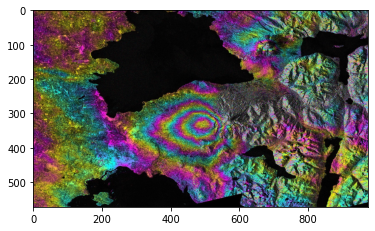

In [ ]:
plt.imshow(image)

In [ ]:
image.shape # h,w,c

(572, 974, 3)

In [ ]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [ ]:
# ROI
img_roi = image[100:200, 500:700]

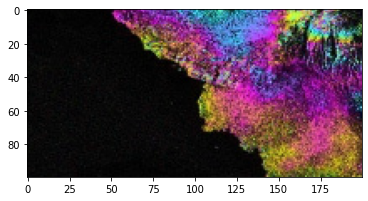

In [ ]:
plt.imshow(img_roi)

In [ ]:
b,g,r = cv2.split(image)

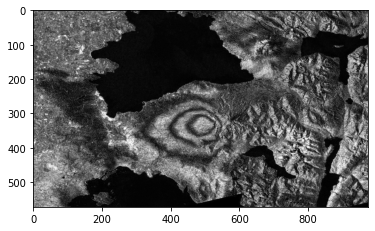

In [ ]:
plt.imshow(b, cmap = 'gray')

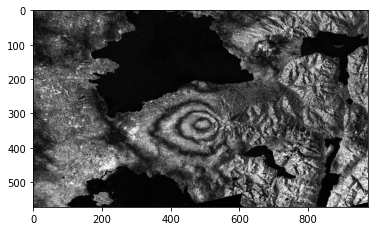

In [ ]:
plt.imshow(g, cmap = 'gray')

In [ ]:
# alternative approach
b = image[:,:,0]

In [ ]:
import copy

image2 = copy.deepcopy(image)

In [ ]:
image2[50:100,50:100] = [0,0,0]

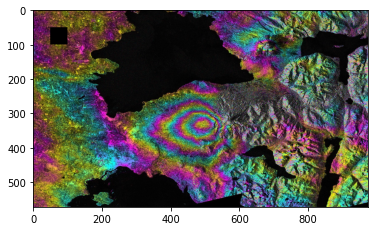

In [ ]:
plt.imshow(image2)

In [ ]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

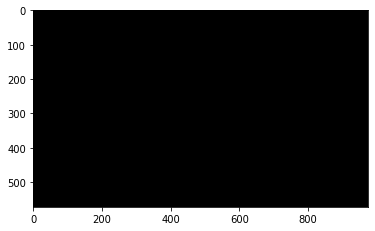

In [ ]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [ ]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [ ]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [ ]:
image_gray[0,0]

40

In [ ]:
image_gray.shape

(572, 974)

In [ ]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [ ]:
image_hsv.shape

(572, 974, 3)

In [ ]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [ ]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [ ]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [ ]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [ ]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

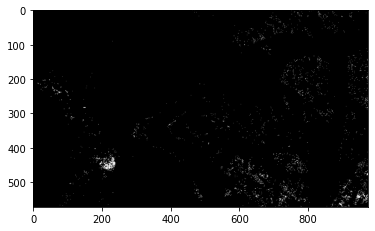

In [ ]:
plt.imshow(thresh1, cmap='gray')

In [ ]:
thresh1[thresh1==100].sum()

0

# Построение гистограммы

In [ ]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

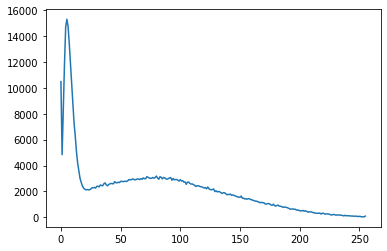

In [ ]:
plt.plot(b_hist)

In [ ]:
b_hist_cum = b_hist.cumsum()

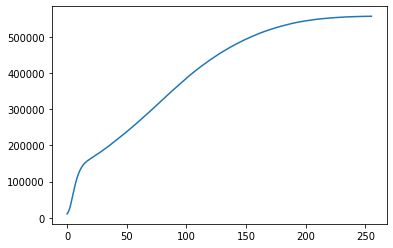

In [ ]:
plt.plot(b_hist_cum)

In [ ]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

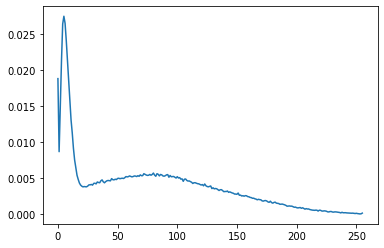

In [ ]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [ ]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


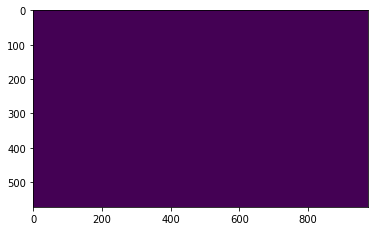

In [ ]:
plt.imshow(diff)

In [ ]:
mse = mean_squared_error(image_gray, image_gray)
mse

0.0

# Статистические характеристики изображений

In [ ]:
mean = image_gray.mean()

In [ ]:
std = image_gray.std()

In [ ]:
print(mean,std)

67.41225535245043 52.016191875959635


In [ ]:
eq_gray = cv2.equalizeHist(image_gray)

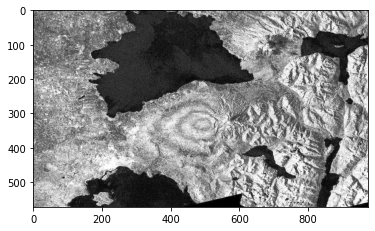

In [ ]:
plt.imshow(eq_gray, cmap="gray")


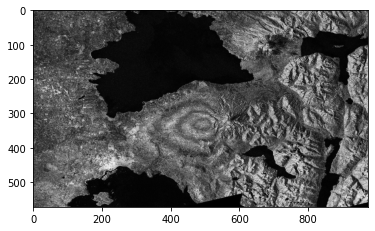

In [ ]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


/tmp/ipykernel_3486/4288600982.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='gray')


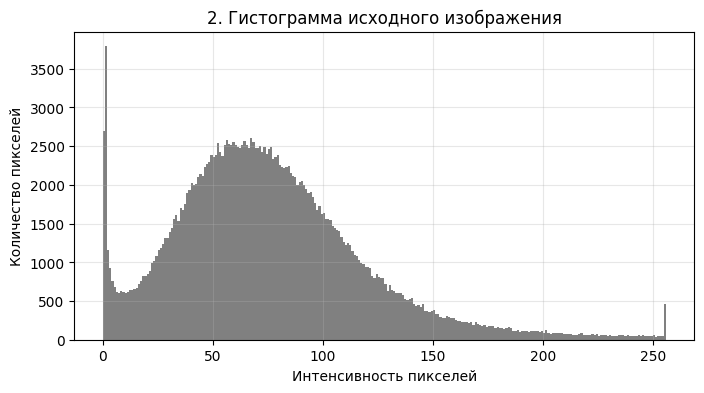

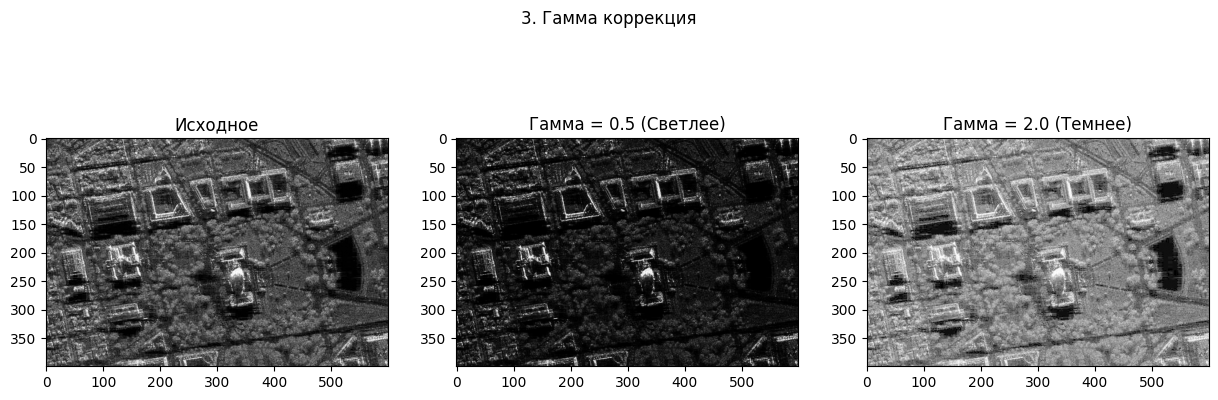

4. Сравнение метрик (MSE и SSIM):
Гамма=0.5 -> MSE: 2383.76 | SSIM: 0.5270
Гамма=2.0 -> MSE: 3250.43 | SSIM: 0.7875
--------------------------------------------------


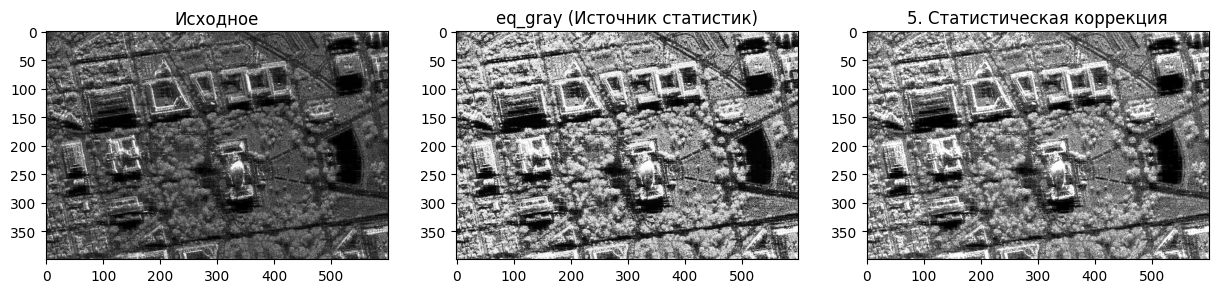

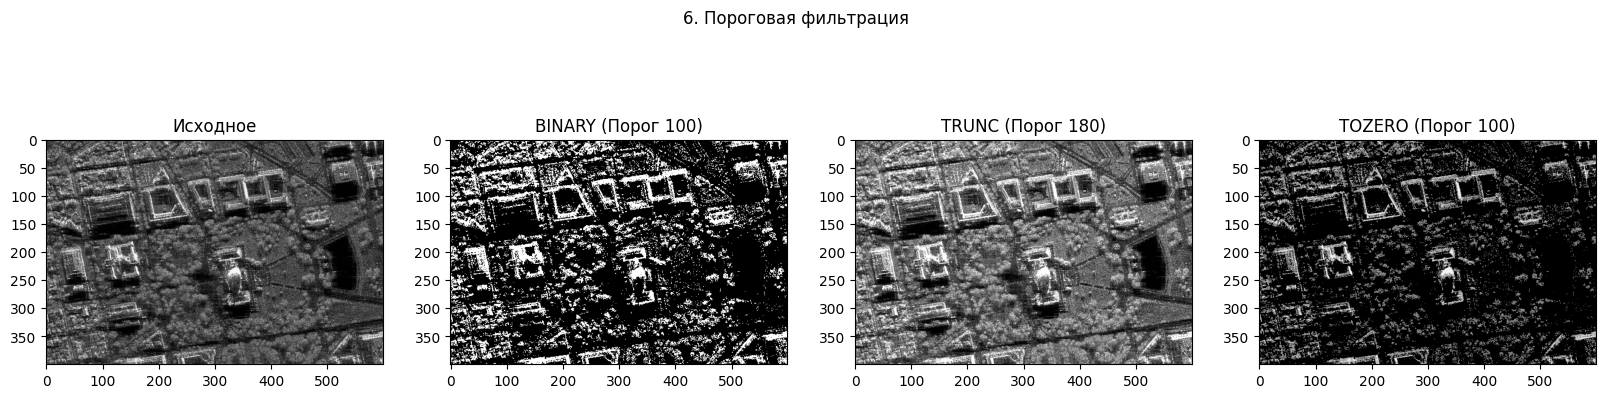

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 4))
plt.hist(img.ravel(), 256, [0, 256], color='gray')
plt.title('2. Гистограмма исходного изображения')
plt.xlabel('Интенсивность пикселей')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)
plt.show()

def custom_histogram_equalization(image):
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_normalized = np.ma.filled(cdf_masked, 0).astype('uint8')
    return cdf_normalized[image]

eq_gray = custom_histogram_equalization(img)

def apply_gamma(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

img_gamma_less = apply_gamma(img, 0.5)
img_gamma_greater = apply_gamma(img, 2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(img_gamma_less, cmap='gray'); axes[1].set_title('Гамма = 0.5 (Светлее)')
axes[2].imshow(img_gamma_greater, cmap='gray'); axes[2].set_title('Гамма = 2.0 (Темнее)')
plt.suptitle('3. Гамма коррекция')
plt.show()

mse_less = mse(img, img_gamma_less)
ssim_less = ssim(img, img_gamma_less)

mse_greater = mse(img, img_gamma_greater)
ssim_greater = ssim(img, img_gamma_greater)

print("4. Сравнение метрик (MSE и SSIM):")
print(f"Гамма=0.5 -> MSE: {mse_less:.2f} | SSIM: {ssim_less:.4f}")
print(f"Гамма=2.0 -> MSE: {mse_greater:.2f} | SSIM: {ssim_greater:.4f}")
print("-" * 50)

def custom_statistical_correction(target, source):
    E_t, D_t = np.mean(target), np.std(target)
    E_s, D_s = np.mean(source), np.std(source)

    if D_t == 0: D_t = 1e-6

    corrected = E_s + (target.astype(np.float32) - E_t) * (D_s / D_t)
    return np.clip(corrected, 0, 255).astype(np.uint8)

img_stat = custom_statistical_correction(img, eq_gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(eq_gray, cmap='gray'); axes[1].set_title('eq_gray (Источник статистик)')
axes[2].imshow(img_stat, cmap='gray'); axes[2].set_title('5. Статистическая коррекция')
plt.show()

thresh_val_1 = 100
thresh_val_2 = 180
max_val = 255

_, thresh_binary = cv2.threshold(img, thresh_val_1, max_val, cv2.THRESH_BINARY)

_, thresh_trunc = cv2.threshold(img, thresh_val_2, max_val, cv2.THRESH_TRUNC)

_, thresh_tozero = cv2.threshold(img, thresh_val_1, max_val, cv2.THRESH_TOZERO)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(thresh_binary, cmap='gray'); axes[1].set_title(f'BINARY (Порог {thresh_val_1})')
axes[2].imshow(thresh_trunc, cmap='gray'); axes[2].set_title(f'TRUNC (Порог {thresh_val_2})')
axes[3].imshow(thresh_tozero, cmap='gray'); axes[3].set_title(f'TOZERO (Порог {thresh_val_1})')
plt.suptitle('6. Пороговая фильтрация')
plt.show()